In [106]:
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Styling
import matplotlib.style as style

style.use("fivethirtyeight")

# Statistics
from scipy.stats import zscore, norm

# Sklearn - Preprocessing
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    
)
from sklearn.impute import SimpleImputer

# Create preprocessing pipeline with ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Model Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)

# Sklearn - Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LinearRegression


# Sklearn - Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Imbalanced Learning
# from imblearn.over_sampling import SMOTE


# Set display options for better readability

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
np.random.seed(42)

# Define the data file path
DATA_PATH = "student-data-25s3.csv"
TARGET = 'G3'  # Define the target variable

# 1. Data Preparation

Load and inspect the dataset for quality issues.

In [26]:
# Load the data
df = pd.read_csv(DATA_PATH)

# Basic info
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (650, 25)
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'traveltime', 'studytime', 'failures', 'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,GP,F,18.0,U,GT3,4,4,at_home,teacher,course,2,2.0,0,no,yes,no,no,4,3,4,3,4,0.0,11.0,11.0
1,GP,F,17.0,U,GT3,1,1,at_home,other,course,1,2.0,0,no,yes,yes,no,5,3,3,3,2,9.0,11.0,11.0
2,GP,F,15.0,U,LE3,1,1,at_home,other,other,1,2.0,0,no,yes,yes,no,4,3,2,3,6,12.0,13.0,12.0
3,GP,F,15.0,U,GT3,4,2,health,services,home,1,3.0,0,yes,yes,yes,yes,3,2,2,5,0,14.0,14.0,14.0
4,GP,F,16.0,U,GT3,3,3,other,other,home,1,2.0,0,no,yes,no,no,4,3,2,5,0,11.0,13.0,13.0


## 2.1 Check Duplicates

In [27]:
# Count duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# View duplicate rows (if any)
if dup_count > 0:
    display(df[df.duplicated(keep=False)])

# Remove duplicates (uncomment to use)
# df = df.drop_duplicates()
# print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 6


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
58,GP,M,15.0,U,LE3,1,2,other,at_home,home,1,2.0,0,yes,yes,yes,no,4,3,2,5,0,14.0,13.0,14.0
59,GP,M,15.0,U,LE3,1,2,other,at_home,home,1,2.0,0,yes,yes,yes,no,4,3,2,5,0,14.0,13.0,14.0
60,GP,M,15.0,U,LE3,1,2,other,at_home,home,1,2.0,0,yes,yes,yes,no,4,3,2,5,0,14.0,13.0,14.0
299,GP,F,20.0,R,GT3,2,1,other,other,course,2,2.0,0,yes,no,yes,yes,1,2,3,2,8,10.0,12.0,12.0
300,GP,F,20.0,R,GT3,2,1,other,other,course,2,2.0,0,yes,no,yes,yes,1,2,3,2,8,10.0,12.0,12.0
301,GP,F,20.0,R,GT3,2,1,other,other,course,2,2.0,0,yes,no,yes,yes,1,2,3,2,8,10.0,12.0,12.0
448,MS,F,16.0,R,GT3,4,4,teacher,teacher,course,2,3.0,0,yes,yes,yes,yes,4,2,2,4,6,16.0,16.0,17.0
468,MS,F,16.0,R,GT3,4,4,teacher,teacher,course,2,3.0,0,yes,yes,yes,yes,4,2,2,4,6,16.0,16.0,17.0
473,MS,F,16.0,R,GT3,4,4,teacher,teacher,course,2,3.0,0,yes,yes,yes,yes,4,2,2,4,6,16.0,16.0,17.0


## 2.2 Check Null Values

In [28]:
# Count null values per column
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percent': null_percent
})
print(null_summary[null_summary['null_count'] > 0])

# Total nulls
print(f"\nTotal null values: {df.isnull().sum().sum()}")

            null_count  null_percent
school               1          0.15
sex                  1          0.15
address              1          0.15
famsize              1          0.15
Mjob                 2          0.31
Fjob                 2          0.31
reason               1          0.15
studytime            6          0.92
activities           1          0.15
higher               1          0.15
internet             1          0.15
romantic             1          0.15

Total null values: 19


## 2.3 Check Unique Values

In [29]:
# Show unique values for each column
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"{col}: {len(unique_vals)} unique values")
    # Show unique values and their counts
    
    for val in unique_vals:
        count = (df[col] == val).sum()
        print(f"  {val}: {count}")
    
    print("-----------")
    

school: 3 unique values
  GP: 423
  MS: 226
  nan: 0
-----------
sex: 3 unique values
  F: 384
  M: 265
  nan: 0
-----------
age: 9 unique values
  18.0: 138
  17.0: 178
  15.0: 111
  16.0: 173
  19.0: 32
  22.0: 1
  20.0: 9
  21.0: 2
  16.762422360248447: 6
-----------
address: 3 unique values
  U: 449
  R: 200
  nan: 0
-----------
famsize: 3 unique values
  GT3: 456
  LE3: 193
  nan: 0
-----------
Medu: 5 unique values
  4: 174
  1: 145
  3: 139
  2: 186
  0: 6
-----------
Fedu: 5 unique values
  4: 130
  1: 175
  2: 209
  3: 129
  0: 7
-----------
Mjob: 6 unique values
  at_home: 134
  health: 46
  other: 262
  services: 133
  teacher: 73
  nan: 0
-----------
Fjob: 6 unique values
  teacher: 37
  other: 365
  services: 179
  health: 23
  at_home: 44
  nan: 0
-----------
reason: 5 unique values
  course: 286
  other: 71
  home: 150
  reputation: 142
  nan: 0
-----------
traveltime: 4 unique values
  2: 216
  1: 364
  3: 53
  4: 17
-----------
studytime: 10 unique values
  2.0: 301
  

## 2.4 Unique Values Count (Value Counts)

In [30]:
# Value counts for a specific column (replace 'column_name')
# df['column_name'].value_counts()

# Value counts with percentages
# df['column_name'].value_counts(normalize=True) * 100

# Value counts including NaN
# df['column_name'].value_counts(dropna=False)

## 2.5 Check Outliers

In [31]:
# IQR Method for outlier detection
def detect_outliers_iqr(df, col):
    """Detect outliers using IQR method"""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), lower, upper

# Check outliers for all numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
print("Outlier Detection (IQR Method):")
print("-" * 60)
for col in numerical_cols:
    count, lower, upper = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers (valid range: {lower:.2f} - {upper:.2f})")

Outlier Detection (IQR Method):
------------------------------------------------------------
age: 1 outliers (valid range: 13.00 - 21.00)
Medu: 0 outliers (valid range: -1.00 - 7.00)
Fedu: 0 outliers (valid range: -2.00 - 6.00)
traveltime: 17 outliers (valid range: -0.50 - 3.50)
studytime: 41 outliers (valid range: -0.50 - 3.50)
failures: 101 outliers (valid range: 0.00 - 0.00)
famrel: 51 outliers (valid range: 2.50 - 6.50)
freetime: 44 outliers (valid range: 1.50 - 5.50)
goout: 0 outliers (valid range: -1.00 - 7.00)
health: 0 outliers (valid range: -2.50 - 9.50)
absences: 22 outliers (valid range: -9.00 - 15.00)
G1: 17 outliers (valid range: 5.50 - 17.50)
G2: 26 outliers (valid range: 5.50 - 17.50)
G3: 16 outliers (valid range: 4.00 - 20.00)


In [32]:
# Z-Score Method for outlier detection
def detect_outliers_zscore(df, col, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(zscore(df[col].dropna()))
    outliers = df[col].dropna()[z_scores > threshold]
    return len(outliers)

print("\nOutlier Detection (Z-Score Method, threshold=3):")
print("-" * 60)
for col in numerical_cols:
    count = detect_outliers_zscore(df, col)
    print(f"{col}: {count} outliers")


Outlier Detection (Z-Score Method, threshold=3):
------------------------------------------------------------
age: 3 outliers
Medu: 0 outliers
Fedu: 0 outliers
traveltime: 17 outliers
studytime: 7 outliers
failures: 15 outliers
famrel: 24 outliers
freetime: 0 outliers
goout: 0 outliers
health: 0 outliers
absences: 9 outliers
G1: 1 outliers
G2: 7 outliers
G3: 16 outliers


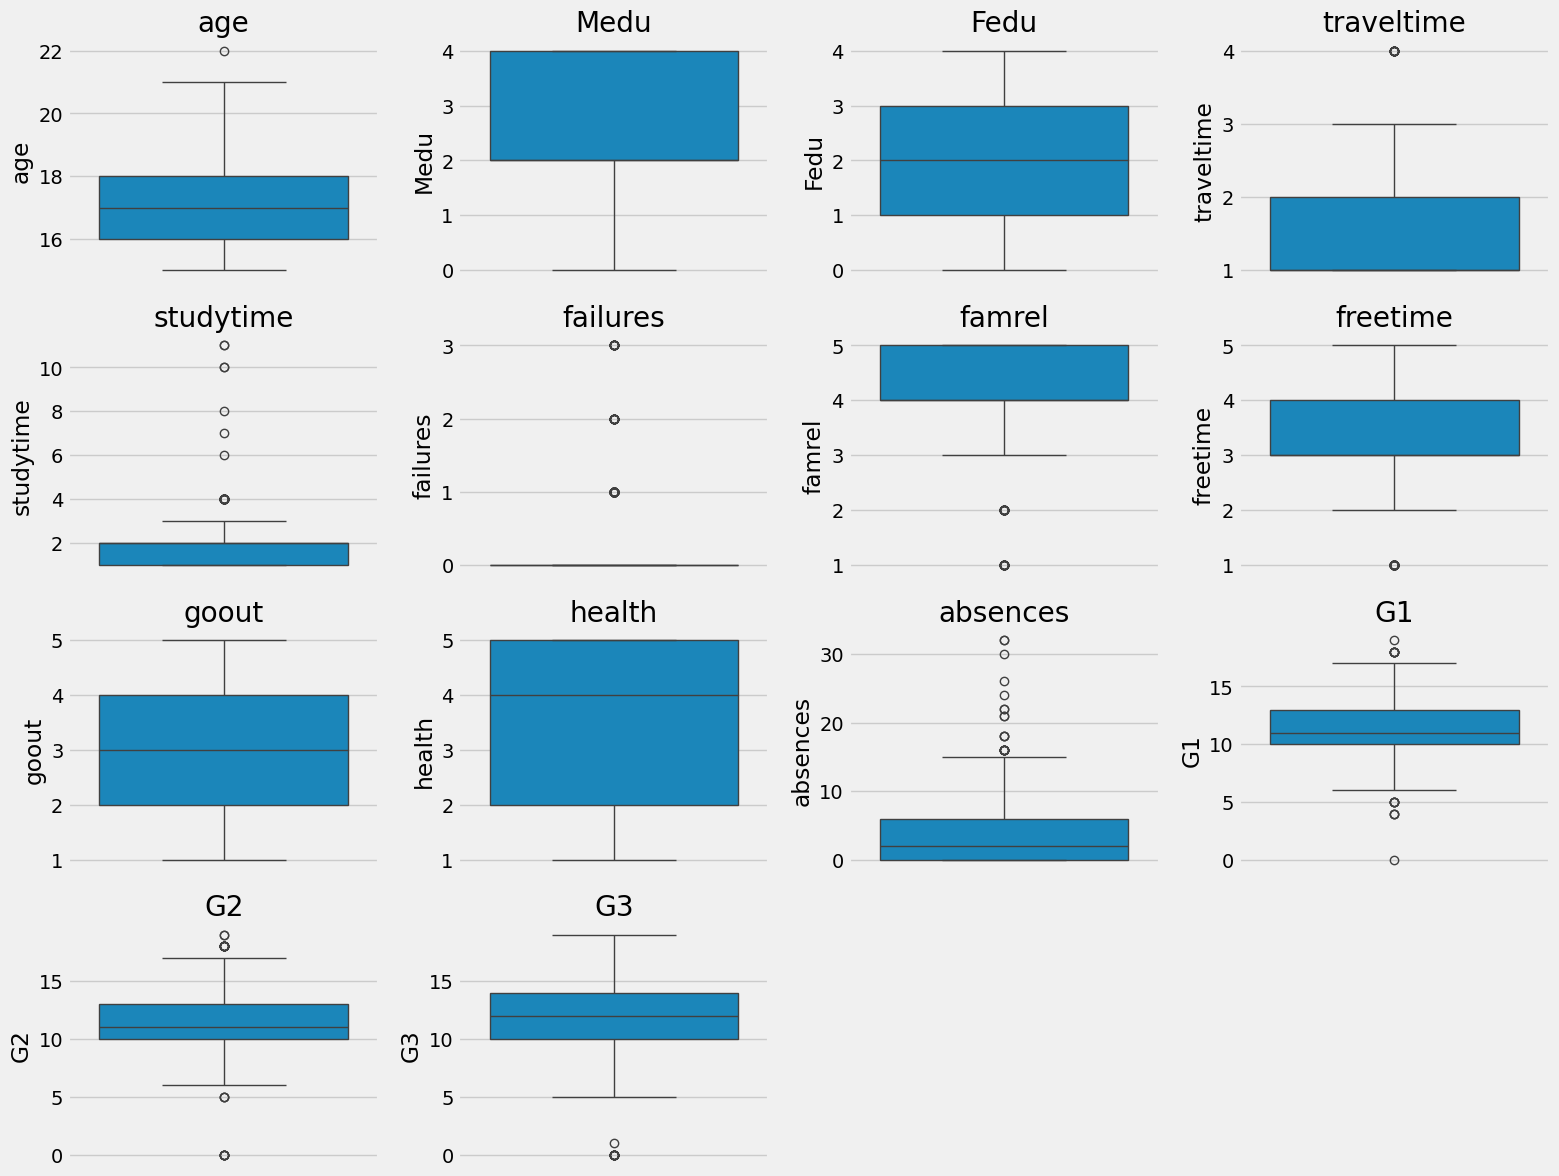

In [33]:
# Visualize outliers with box plots
n_cols = 4
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

# Hide empty subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 3.1 Encoding Categorical Variables

In [50]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# remove target from categorical and numerical columns
if TARGET in cat_cols:
    cat_cols.remove(TARGET)
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

# 3. Feature Preprocessing# Data Modelling

In [87]:
# Define features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

y = y.apply(lambda x: 1 if x >= 10 else 0)

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (520, 24)
Test shape: (130, 24)


In [88]:
# Define column groups (customize these based on your data)

# Columns for one-hot encoding (nominal categorical - no order)
onehot_cols = cat_cols  # e.g., ['school', 'sex', 'address']

# Columns for ordinal encoding (ordinal categorical - with order)
ordinal_cols = []  # columns with natural order
ord_categories = {
    # "size": ["small", "medium", "large"],
    # "education": ["high_school", "bachelor", "master"],
}

# Columns for standardization (z-score)
standardize_cols = []  # e.g., ['age', 'absences']

# Columns for min-max scaling
minmax_cols = numerical_cols  # e.g., ['G1', 'G2']

# Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
                ]
            ),
            onehot_cols,
        ),
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("minmax", MinMaxScaler()),
                ]
            ),
            minmax_cols,
        ),
        # ('ordinal', OrdinalEncoder(categories=list(ord_categories.values())), ordinal_cols),
        # ('standardize', StandardScaler(), standardize_cols),
    ],
    remainder="passthrough",  # Drop columns not specified
)

# Create preprocessing pipeline
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
    ]
)

# Fit the pipeline
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")

Pipeline fitted successfully!


In [89]:
X_train_pre = pipeline.transform(X_train)
X_test_pre = pipeline.transform(X_test)

In [90]:
def train_and_plot(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    print("Model accuracy for train set: {0:.3f}".format(model.score(X_train, y_train)))
    print("Model accuracy for test set: {0:.3f}".format(model.score(X_test, y_test)))

    y_pred = model.predict(X_test)

    # Classification Report
    print("\n{}".format(classification_report(y_test, y_pred)))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    # Accuracy Score
    auc = accuracy_score(y_test, y_pred)
    print("\nAccuracy Score: ", round(auc, 3))

    # ROC Curve
    model_roc_auc = roc_auc_score(y_test, model.predict(X_test))
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.figure(figsize=(12.8, 6))
    plt.plot(fpr, tpr, label="AUC = {})".format(round(model_roc_auc, 4)))
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver operating characteristic")
    plt.legend(loc="lower right")
    plt.show()

    return model

# Base Logistic Regression

Model accuracy for train set: 0.917
Model accuracy for test set: 0.915

              precision    recall  f1-score   support

           0       0.88      0.41      0.56        17
           1       0.92      0.99      0.95       113

    accuracy                           0.92       130
   macro avg       0.90      0.70      0.76       130
weighted avg       0.91      0.92      0.90       130


Confusion Matrix:
 [[  7  10]
 [  1 112]]

Accuracy Score:  0.915


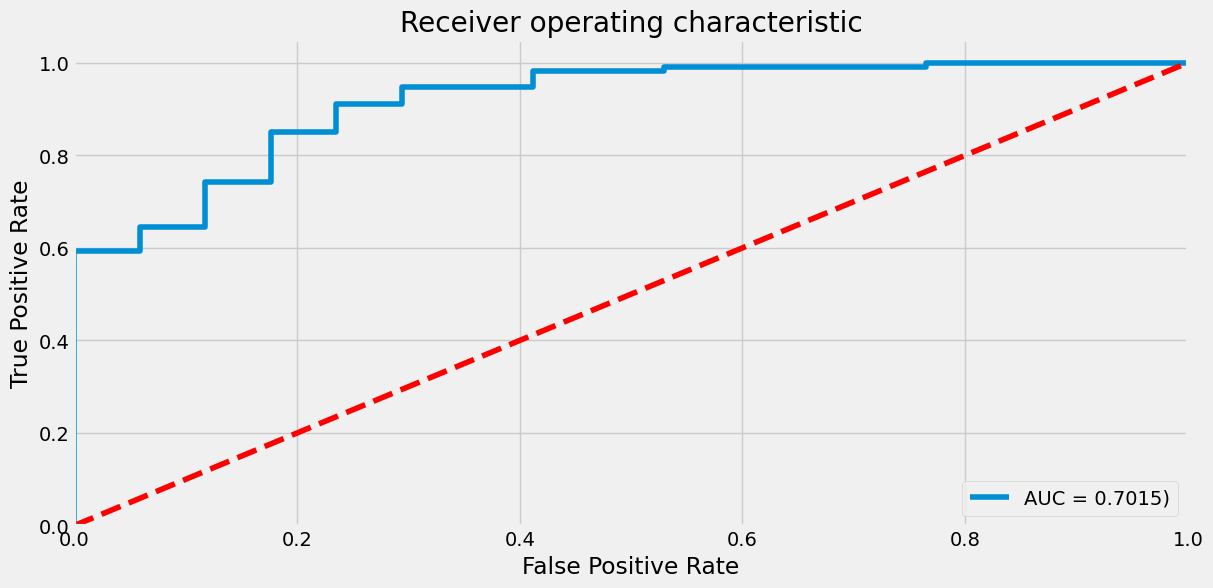

In [91]:
lr = LogisticRegression(random_state=42)
lr_model = train_and_plot(lr, X_train_pre, y_train, X_test_pre, y_test)

## LR with hyperparameter tuning

c:\Users\itsla.000\Documents\GitHub\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
300 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\itsla.000\Documents\GitHub\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\itsla.000\Documents\GitHub\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\

Model accuracy for train set: 0.950
Model accuracy for test set: 0.931

              precision    recall  f1-score   support

           0       0.90      0.53      0.67        17
           1       0.93      0.99      0.96       113

    accuracy                           0.93       130
   macro avg       0.92      0.76      0.81       130
weighted avg       0.93      0.93      0.92       130


Confusion Matrix:
 [[  9   8]
 [  1 112]]

Accuracy Score:  0.931


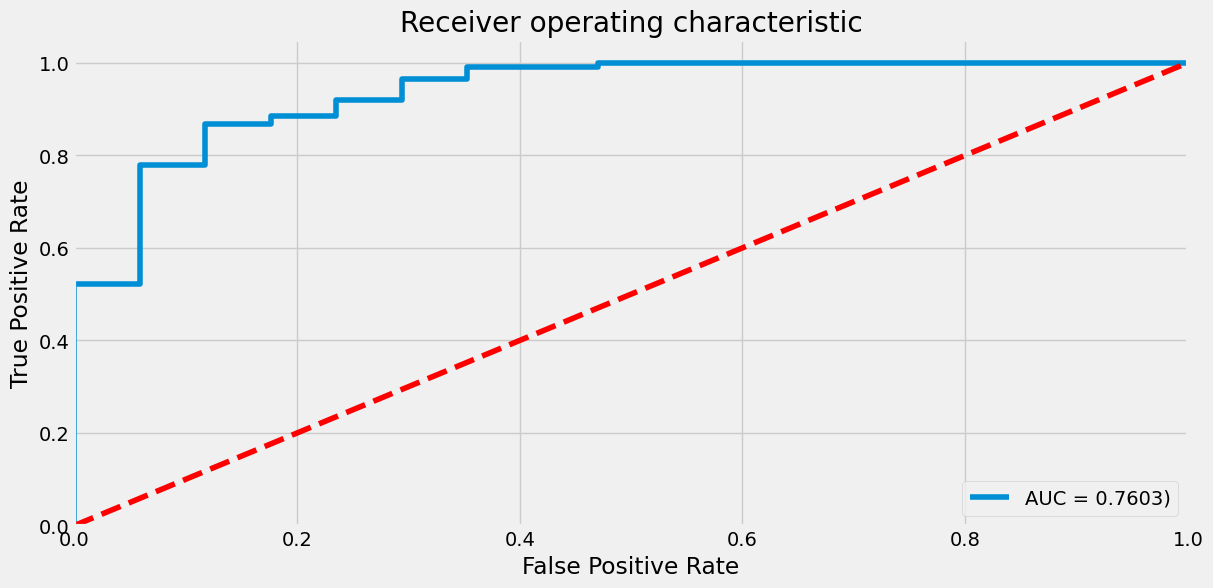

In [98]:
LR = LogisticRegression()

params = {
    "penalty": ["l1", "l2"],
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "max_iter": [100, 110, 120, 130, 140],
}

skf = StratifiedKFold(n_splits=10)
LR_hyper = GridSearchCV(LR, param_grid=params, n_jobs=-1, cv=skf)

lr_hyper_model = train_and_plot(LR_hyper, X_train_pre, y_train, X_test_pre, y_test)

# Base Decision Tree Model

Model accuracy for train set: 1.000
Model accuracy for test set: 0.854

              precision    recall  f1-score   support

           0       0.45      0.53      0.49        17
           1       0.93      0.90      0.91       113

    accuracy                           0.85       130
   macro avg       0.69      0.72      0.70       130
weighted avg       0.86      0.85      0.86       130


Confusion Matrix:
 [[  9   8]
 [ 11 102]]

Accuracy Score:  0.854


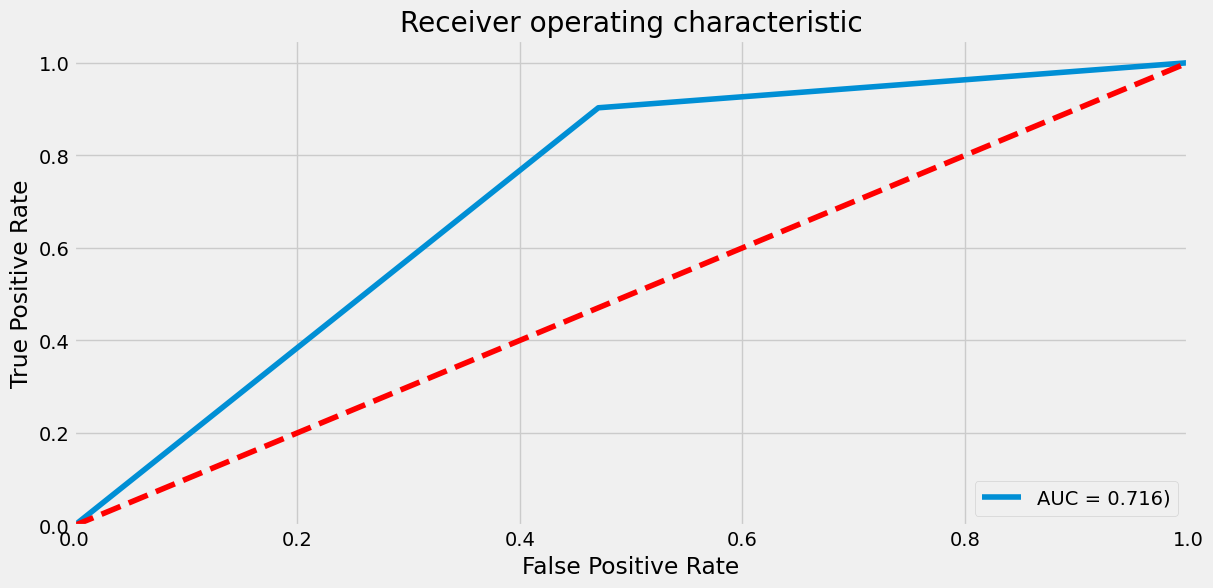

In [95]:
# Base Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)

dt_model = train_and_plot(dt, X_train_pre, y_train, X_test_pre, y_test)

# Base KNN model


Model accuracy for train set: 0.856
Model accuracy for test set: 0.892

              precision    recall  f1-score   support

           0       1.00      0.18      0.30        17
           1       0.89      1.00      0.94       113

    accuracy                           0.89       130
   macro avg       0.94      0.59      0.62       130
weighted avg       0.90      0.89      0.86       130


Confusion Matrix:
 [[  3  14]
 [  0 113]]

Accuracy Score:  0.892


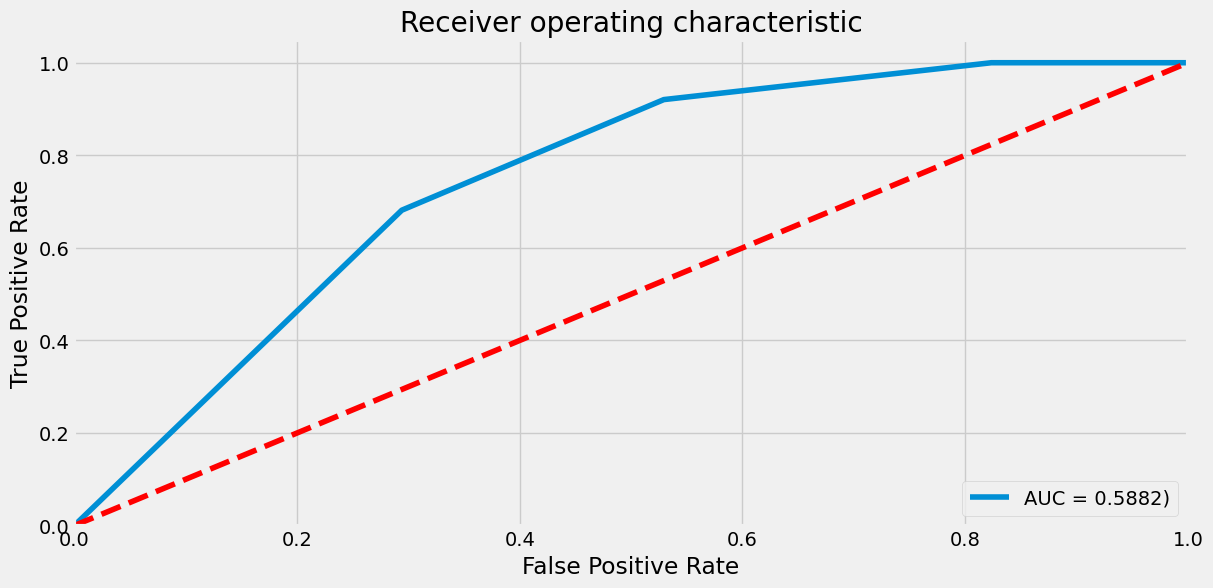

In [ ]:
# KNN b

knn = KNeighborsClassifier()
knn_model = train_and_plot(knn, X_train_pre, y_train, X_test_pre, y_test)

Model accuracy for train set: 1.000
Model accuracy for test set: 0.869

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.87      1.00      0.93       113

    accuracy                           0.87       130
   macro avg       0.43      0.50      0.47       130
weighted avg       0.76      0.87      0.81       130


Confusion Matrix:
 [[  0  17]
 [  0 113]]

Accuracy Score:  0.869


c:\Users\itsla.000\Documents\GitHub\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\itsla.000\Documents\GitHub\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\itsla.000\Documents\GitHub\PDS---Test-Prep\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

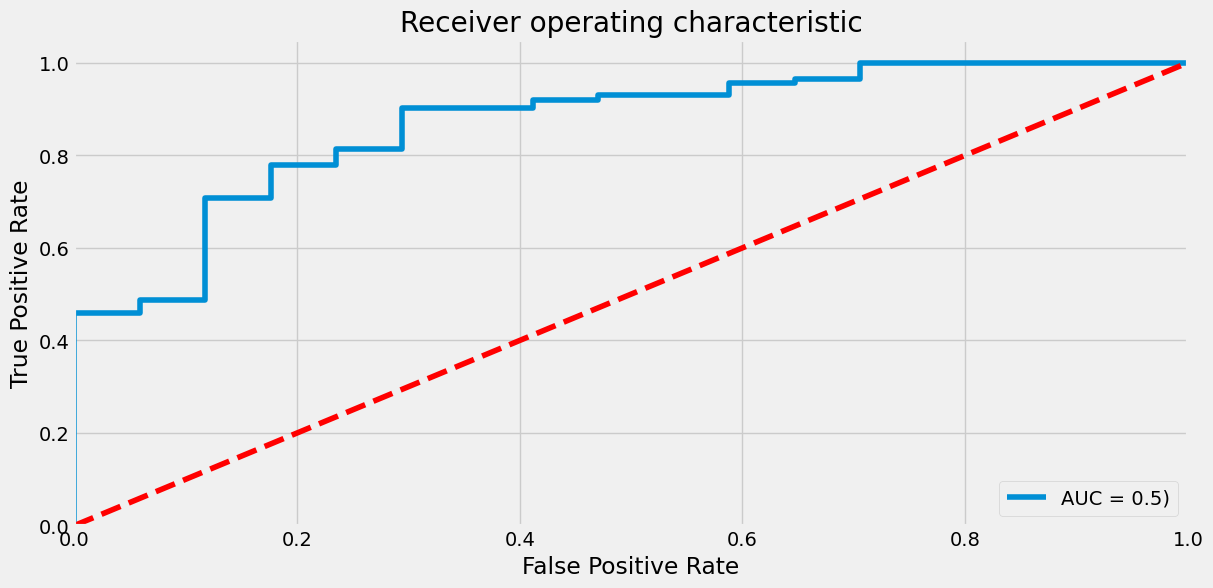

In [99]:
# KNN with hyperparameter tuning
KNN = KNeighborsClassifier()

params = {
    "n_neighbors": list(range(1, 40, 2)),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

skf = StratifiedKFold(n_splits=10)
KNN_hyper = GridSearchCV(KNN, param_grid=params, n_jobs=-1, cv=skf)

knn_model_hyper = train_and_plot(KNN_hyper, X_train_pre, y_train, X_test_pre, y_test)

# Base Random Forest Model

Model accuracy for train set: 1.000
Model accuracy for test set: 0.915

              precision    recall  f1-score   support

           0       0.80      0.47      0.59        17
           1       0.93      0.98      0.95       113

    accuracy                           0.92       130
   macro avg       0.86      0.73      0.77       130
weighted avg       0.91      0.92      0.91       130


Confusion Matrix:
 [[  8   9]
 [  2 111]]

Accuracy Score:  0.915


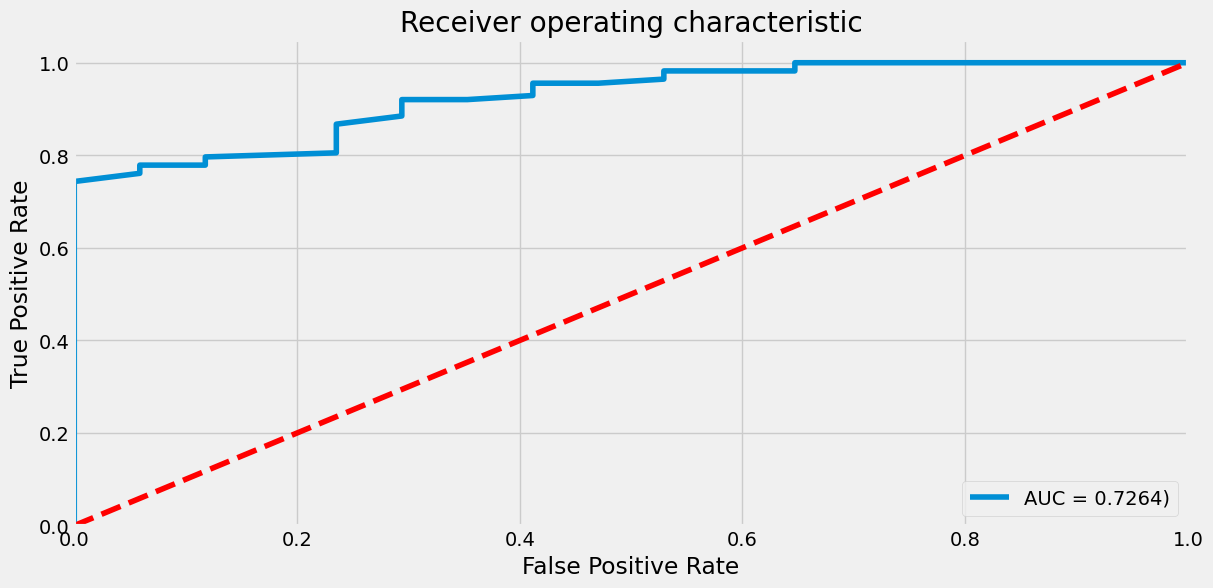

In [97]:
rf = RandomForestClassifier(random_state=42)

rf_model = train_and_plot(rf, X_train_pre, y_train, X_test_pre, y_test)

# Regression

In [111]:
# Define features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Basic split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (520, 24)
Test shape: (130, 24)


In [112]:
pipeline.fit(X_train, y_train)
X_train_pre = pipeline.transform(X_train)
X_test_pre = pipeline.transform(X_test)

In [113]:
def train_and_plot_regression(model, X_train, y_train, X_test, y_test):
    """Train regression model and display relevant metrics"""
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R² Score
    print(f"R² Score (Train): {r2_score(y_train, y_train_pred):.3f}")
    print(f"R² Score (Test):  {r2_score(y_test, y_test_pred):.3f}")

    # MSE & RMSE
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    print(f"\nMSE:  {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")

    # MAE
    mae = mean_absolute_error(y_test, y_test_pred)
    print(f"MAE:  {mae:.3f}")

    # Residual Plot
    residuals = y_test - y_test_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Predicted vs Actual
    axes[0].scatter(y_test, y_test_pred, alpha=0.5)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predicted")
    axes[0].set_title("Predicted vs Actual")

    # Residuals distribution
    axes[1].hist(residuals, bins=30, edgecolor="black")
    axes[1].set_xlabel("Residuals")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Residuals Distribution")

    plt.tight_layout()
    plt.show()

    return model

## Base Linear Regression

R² Score (Train): 0.866
R² Score (Test):  0.820

MSE:  1.772
RMSE: 1.331
MAE:  0.766


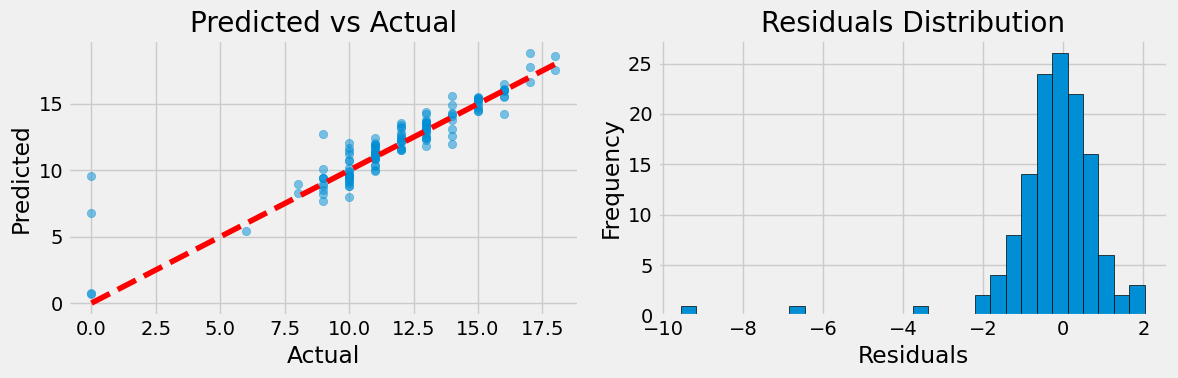

In [114]:
lr = LinearRegression()

lr_model = train_and_plot_regression(lr, X_train_pre, y_train, X_test_pre, y_test)

In [ ]:
# KNN with hyperparameter tuning
KNN = KNeighborsClassifier()

params = {
    "n_neighbors": list(range(1, 40, 2)),
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
}

skf = StratifiedKFold(n_splits=10)
KNN_hyper = GridSearchCV(KNN, param_grid=params, n_jobs=-1, cv=skf)

knn_model_hyper = train_and_plot(KNN_hyper, X_train_pre, y_train, X_test_pre, y_test)